# **Import Library & Load Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv('googleplaystore.csv')

# lihat data awal
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


# **Cek Struktur Data**

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


# **Data Cleaning**

## **3.1 Hapus data duplikat**

In [ ]:
df = df.drop_duplicates()

## **3.2 Hapus missing value**

In [ ]:
df.isnull().sum()

df = df.dropna()

## **3.3 Membersihkan kolom Installs**

In [ ]:
df['Installs'] = df['Installs'].str.replace(',', '')
df['Installs'] = df['Installs'].str.replace('+', '')
df['Installs'] = df['Installs'].astype(int)

## **3.4 Membersihkan kolom Price**

In [ ]:
df['Price'] = df['Price'].str.replace('$', '')
df['Price'] = df['Price'].astype(float)

## **3.5 Membersihkan Kolom Size**

In [ ]:
def convert_size(size):
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size:
        return float(size.replace('k', '')) / 1024
    else:
        return np.nan

df['Size'] = df['Size'].apply(convert_size)

# **EDA (Exploratory Data Analyst**

## **4.1 Distribusi Rating**

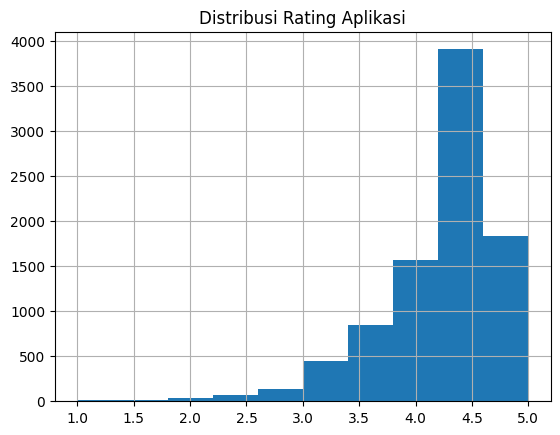

In [ ]:
plt.figure()
df['Rating'].hist()
plt.title('Distribusi Rating Aplikasi')
plt.show()

## **4.2 Kategori Terbanyak**

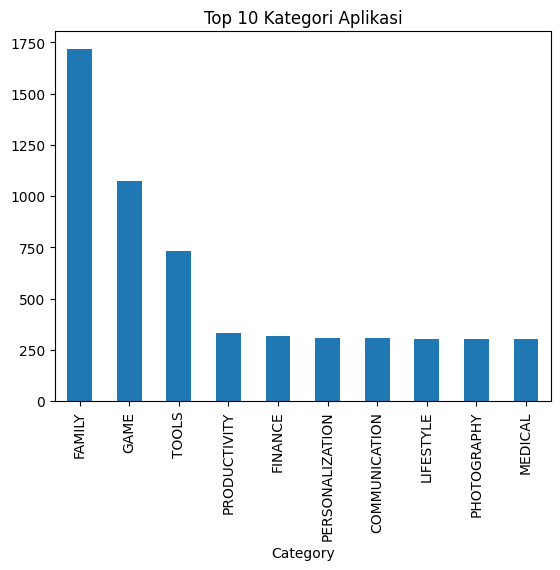

In [ ]:
plt.figure()
df['Category'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Kategori Aplikasi')
plt.show()

## **4.3 Rating vs Installs**

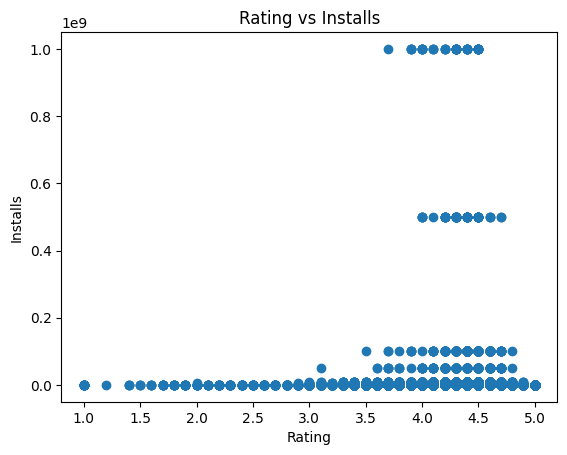

In [ ]:
plt.figure()
plt.scatter(df['Rating'], df['Installs'])
plt.title('Rating vs Installs')
plt.xlabel('Rating')
plt.ylabel('Installs')
plt.show()

## **4.4 Free vs Paid**

In [ ]:
df.groupby('Type')['Installs'].mean()

,Installs
Type,
Free,1.771060e+07
Paid,1.131939e+05


# **5. Modeling**

## **5.1 Membuat Target (Success / Tidak)**

In [ ]:
# membuat label sukses (1) dan tidak (0)
df['Success'] = df['Installs'].apply(lambda x: 1 if x > 100000 else 0)

df['Success'].value_counts()

,count
Success,
1,4566
0,4320


## **5.2 Pilih Feature**

In [ ]:
features = ['Rating', 'Size', 'Price']
X = df[features]
y = df['Success']

## **5.3 Handle Missing Value**

In [ ]:
X = X.fillna(X.median())

## **5.4 Split Data**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **5.5 Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **5.6 Modeling (Logistic Regression)**

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

# **6. Evaluasi**

## **6.1 Prediksi**

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# **6.2 Accuracy**

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6439820022497188


## **6.3 Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[498 377]
 [256 647]]


## **6.4 Precision, Recall**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.57      0.61       875
           1       0.63      0.72      0.67       903

    accuracy                           0.64      1778
   macro avg       0.65      0.64      0.64      1778
weighted avg       0.65      0.64      0.64      1778



## **6.5 AUC Score**

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

AUC: 0.684249960449296
